Este es el proyecto de predictor de precio de un ordenador portátil. Voy a aplicar los conocimientos aprendidos sobre Aprendizaje Supervisado y Regresión Lineal del curso de Andrew Ng.

# 1. Importaciones de librerías necesarias

In [110]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 2. Cargar los datos

In [111]:
df = pd.read_csv('laptop_data.csv')

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   TypeName          1303 non-null   str    
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   str    
 5   Cpu               1303 non-null   str    
 6   Ram               1303 non-null   str    
 7   Memory            1303 non-null   str    
 8   Gpu               1303 non-null   str    
 9   OpSys             1303 non-null   str    
 10  Weight            1303 non-null   str    
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), str(9)
memory usage: 122.3 KB


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [112]:
# Separación de datos

# Voy a descartar las columnas de GPU y OpSys
df = df.drop(columns=['Gpu', 'OpSys', 'TypeName', 'ScreenResolution', 'Unnamed: 0'])



In [113]:
# Primero limpio las columnas para que sean solo números (borrar unidades)
df['Ram'] = df['Ram'].str.replace('GB', '').astype(int)
df['Weight'] = df['Weight'].str.replace('kg', '').astype(float)

# Implemento una función para extraer los GB de Memory
def gb_memory(texto):
    texto = str(texto)
    if 'TB' in texto:
        num = float(texto.split('TB')[0].split()[-1])
        return int(num * 1024) # Lo devuelvo en GB
    elif 'GB' in texto:
        num = float(texto.split('GB')[0].split()[-1])
        return int(num)

df['Memory'] = df['Memory'].apply(gb_memory) 

# Función para limpiar la columna Cpu
def procesadores(texto):
    texto = str(texto)
    if 'Intel Core i7' in texto:
        return 'Intel Core i7'
    elif 'Intel Core i5' in texto:
        return 'Intel Core i5'
    elif 'Intel Core i3' in texto:
        return 'Intel Core i3'
    elif 'Intel' in texto:
        return 'Otros Intel'
    elif 'AMD' in texto: 
        return 'AMD'
    else:
        return None

df['Cpu'] = df['Cpu'].apply(procesadores)

def eliminar_companys(df):
    marcas = ['Apple', 'Asus', 'HP', 'Dell', 'Lenovo']
    df_filtrado = df[df['Company'].isin(marcas)].copy()
    df_filtrado = df_filtrado.reset_index(drop=True) #Reseteo los index
    return df_filtrado

df = eliminar_companys(df)

df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1047 entries, 0 to 1046
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  1047 non-null   str    
 1   Inches   1047 non-null   float64
 2   Cpu      1047 non-null   str    
 3   Ram      1047 non-null   int64  
 4   Memory   1047 non-null   int64  
 5   Weight   1047 non-null   float64
 6   Price    1047 non-null   float64
dtypes: float64(3), int64(2), str(2)
memory usage: 57.4 KB


,Company,Inches,Cpu,Ram,Memory,Weight,Price
0,Apple,13.3,Intel Core i5,8,128,1.37,71378.6832
1,Apple,13.3,Intel Core i5,8,128,1.34,47895.5232
2,HP,15.6,Intel Core i5,8,256,1.86,30636.0000
3,Apple,15.4,Intel Core i7,16,512,1.83,135195.3360
4,Apple,13.3,Intel Core i5,8,256,1.37,96095.8080


In [114]:
# Ahora aplico get_dummies a Company y Cpu para que todo el dataset sean numeros
df_procesado = pd.get_dummies(df, columns=['Company', 'Cpu'], drop_first=True, dtype=int)
    # drop_first elimina la columna original sobre la que se aplica get_dummies
    # dtype hace que las columnas que se creen sean int, por defecto son booleanas

df_procesado.head()

,Inches,Ram,Memory,Weight,Price,Company_Asus,Company_Dell,Company_HP,Company_Lenovo,Cpu_Intel Core i3,Cpu_Intel Core i5,Cpu_Intel Core i7,Cpu_Otros Intel
0,13.3,8,128,1.37,71378.6832,0,0,0,0,0,1,0,0
1,13.3,8,128,1.34,47895.5232,0,0,0,0,0,1,0,0
2,15.6,8,256,1.86,30636.0000,0,0,1,0,0,1,0,0
3,15.4,16,512,1.83,135195.3360,0,0,0,0,0,0,1,0
4,13.3,8,256,1.37,96095.8080,0,0,0,0,0,1,0,0


Ya tengo todo el dataset limpio y preparado. Ahora voy a separarlo en X e y, y en train y test.

In [115]:
X = df_procesado.drop(columns=['Price']).values
y = df_procesado['Price'].values

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

Dimensiones de X: (1047, 12)
Dimensiones de y: (1047,)


In [116]:
# Ahora separo los conjuntos de TRAIN y TEST
# uso el método train_test_split de scikit-learn

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ejemplos para entrenar (test): {X_train.shape}")
print(f"Ejemplos para probar (test): {X_test.shape}")

Ejemplos para entrenar (test): (837, 12)
Ejemplos para probar (test): (210, 12)


### Función para normalizar los datos de entrada

In [117]:
def normalizar_zscore(X):
    media = np.mean(X, axis=0)   #vector con la media de cada columna
    desv = np.std(X, axis=0)     #vector con la desviacion de cada columna
    X_norm = (X - media) / desv  #normalizo X

    return X_norm, media, desv
    
print("X sin normalizar:") 
print(X_train[:5])

X_train_n, media, desv = normalizar_zscore(X)
print("X normalizada:") 
print(X_train_n[:5])

X sin normalizar:
[[ 15.6    4.   500.     1.86   0.     0.     1.     0.     0.     1.
    0.     0.  ]
 [ 13.3    8.   512.     1.2    1.     0.     0.     0.     0.     0.
    0.     1.  ]
 [ 11.6    4.   500.     1.47   0.     1.     0.     0.     0.     0.
    0.     1.  ]
 [ 15.6   24.   512.     2.24   1.     0.     0.     0.     0.     0.
    1.     0.  ]
 [ 13.3    8.   256.     1.24   0.     1.     0.     0.     0.     1.
    0.     0.  ]]
X normalizada:
[[-1.22563283 -0.06404995 -1.08794613 -1.02392603 -0.42157773 -0.62928531
  -0.59536806 -0.62928531 -0.34263092  1.40514477 -0.82170554 -0.34436862]
 [-1.22563283 -0.06404995 -1.08794613 -1.06985911 -0.42157773 -0.62928531
  -0.59536806 -0.62928531 -0.34263092  1.40514477 -0.82170554 -0.34436862]
 [ 0.41296722 -0.06404995 -0.78744203 -0.2736857  -0.42157773 -0.62928531
   1.67963326 -0.62928531 -0.34263092  1.40514477 -0.82170554 -0.34436862]
 [ 0.27048026  1.53262378 -0.18643381 -0.31961878 -0.42157773 -0.62928531
  -0.59536

In [118]:
def calcular_coste(X, y, w, b):
    # Impelementacion vectorizada de la funcion de coste
    m = X.shape[0]
    predicciones = np.dot(X, w) + b
    errores = predicciones - y
    suma_errores = np.sum(errores ** 2)
    coste = 1 / (2*m) * suma_errores
    return coste

num_param = X_train.shape[1]
w_prueba = np.zeros(num_param)
coste = calcular_coste(X_train, y_train, w_prueba, 0)
print(coste)

2499108307.677551


### Funciones para cáluclo de gradiente y descenso de gradiente

In [119]:
def calculo_gradiente(X, y, w, b):
    m,n = X.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.0

    for i in range(m):
        err = (np.dot(X[i], w) + b) - y[i]
        for j in range(n):
            dj_dw[j] += err * X[i,j]
        dj_db += err
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

def descenso_gradiente(X, y, w_in, b_in, alpha, num_iters):
    w = w_in.copy()
    b = b_in
    historial_coste = []
    
    for i in range(num_iters):
        dj_dw, dj_db = calculo_gradiente(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        coste = calcular_coste(X, y, w,  b)
        historial_coste.append(coste)

        if i%100 == 0:
            print(f"Iteración {i}: coste = {coste}")
    return w, b, historial_coste
        

Iteración 0: coste = 2380067344.5223966
Iteración 100: coste = 529011207.69337124
Iteración 200: coste = 298538116.68371415
Iteración 300: coste = 264618298.01831836
Iteración 400: coste = 258422710.11270806
Iteración 500: coste = 256718888.8731274
Iteración 600: coste = 255944799.57664305
Iteración 700: coste = 255445638.51313075
Iteración 800: coste = 255064202.49734926
Iteración 900: coste = 254749995.5969962


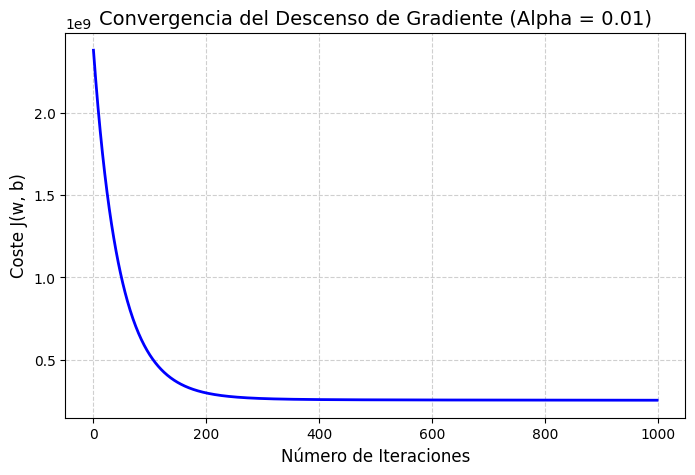

In [120]:
# Pruebas del descenso de gradiente
w_inicial = np.zeros(X_train_n.shape[1])
b_inicial = 0
w, b, historial_coste = descenso_gradiente(X_train_n, y, w_inicial, b_inicial, 0.01, 1000)

# Graficar el descenso de gradiente
plt.figure(figsize=(8, 5))
plt.plot(historial_coste, color='blue', linewidth=2)

plt.title("Convergencia del Descenso de Gradiente (Alpha = 0.01)", fontsize=14)
plt.xlabel("Número de Iteraciones", fontsize=12)
plt.ylabel("Coste J(w, b)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()


In [121]:
# 1. Normalizamos X_test usando el 'mu' y 'sigma' del entrenamiento
X_test_n = (X_test - mu) / sigma

# 2. Hacemos las predicciones sobre test
predicciones_test = np.dot(X_test_n, w) + b

# 3. Vemos el error real en Euros
mae_test = np.mean(np.abs(predicciones_test - y_test))
print(f"Error medio en datos de test: {mae_test:,.2f} €")

NameError: name 'mu' is not defined

# HOJA DE RUTA DEL PROYECTO

1. Limpieza y transformación de los datos
2. Separación de variables y escalado
3. Programar el algoritmo desde cero
4. Entrenamiento y diagnóstico
5. Comparación con scikit-learn